In [1]:
from general_imports import *

In [72]:
def BA(r,tau):
    """These are made to closley match eq 75 and eq 53-54 of Entropy of entaglment and correlations induced by a quench: paper by Cincio and Jacek Dziarmaga"""
    tau=tau+0j
    
    def delta(i,j):
        if i==j:
            return 1
        else:
            return 0
    sign = (r/abs(r) if abs(r) != 0 else 0)
    ltau = log(tau)
    ltau2 = ltau*ltau
    deltas = delta(1,abs(r))+sign*delta(1,abs(r))
    #exponents
    exp_1 = -r*r/8/pi/tau

    exp_2_num = -pi *r*r+1j*r*r*ltau-8j*tau*tau*ltau2
    exp_2_den = 4*tau*ltau2
    exp_2 = exp_2_num/exp_2_den

    exp_3 = -pi *r*r/(4*tau*ltau2)

    #Prefactors
    p1 = - sqrt(2)/pi/sqrt(tau)
    p2 = -2 /sqrt(pi)/sqrt(tau)/sqrt(ltau)

    return 1/2*(p1*exp(exp_1)+deltas+np.real(sign*p2*exp(exp_2)*sqrt(1-exp(exp_3))))
    

def D(n,taus):
    """Strange Convention, n = r-1"""
    r = n+1
    return BA(r,taus)

def sigma_general(indices,tau):
    def remove_duplicates_in_pairs(vec):
      unique_vals, counts = np.unique(vec, return_counts=True)
      filtered_vals = unique_vals[counts % 2 != 0]
      return filtered_vals.tolist()
    #Sigma matrices on different sites commute
    indices = np.sort(indices)
    #Remove any duplicates as sigma_x^2 = 1
    indices = remove_duplicates_in_pairs(indices)
    #Bs sit on odd sites
    odd_sites = np.array(indices[::2])
    #As site on even sites
    even_sites= np.array(indices[1::2])
    #Get string lengths
    JW_string_lengths = even_sites-odd_sites
    #Sum of string lengths is size of matrix needed
    N = sum(JW_string_lengths)
    #Fill in indices for strings
    R = []
    for i in range(0, len(indices), 2):
        start = indices[i]
        end = indices[i+1]
        R.extend(range(start, end+1))

    A_coords = [x for x in R if x not in odd_sites]
    B_coords = [x for x in R if x not in even_sites]
    C = np.zeros((N,N),dtype=complex)
    for nx in range(N):
        for ny in range(N):
            Bx = B_coords[nx]
            Ay = A_coords[ny]
            Nd = Bx-Ay+1
            C[nx,ny] = D(Nd,tau)
    return np.linalg.det(C)


################################################
#           PPROJECTORS
################################################
def binomial_expansion(indices):
    """
    Computes the pairs of combinations of indices.
    """
    pairs = list(combinations(indices, 2))
    return pairs

def all_combinations(indices):
    """
    Computes all combinations of all lengths of indices.
    """
    x = []
    for r in range(len(indices) + 1):
        x.extend(combinations(indices, r))
    return list(x)

def unique_elements_and_frequencies(vec):
    unique_vals, freqs = np.unique(vec, return_counts=True)
    return unique_vals, freqs


def P_n(n,taus, even = True):
    """
    P_n scales directly with the number of terms since even small odd sigma correlations need larger support to calcualte.
    Taking out odd terms works to make easier, but scaling is still 2^n.
    Minor improvements can still be had though.
    """
    #For most cases we use periodic boundary conditions
    #That said, watch out for this definition of indices
    indices = [i for i in range(0,n)]
    terms = all_combinations(indices)

    ###
    x_c = []
    for a in terms[1:]:
      
        a = np.array(a)
        x_c.append(tuple(a - a[0]))  # convert to tuple for hashing
    counter = Counter(x_c)

    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = np.array(list(counter.values()))

    ##
    dat = []

    for term in range(len(vecs)):
        indices = vecs[term]
        degen = counts[term]

        if len(indices)%2 == 1:
            if even ==True:
                dat.append(0)
            else:
                constant = len(k)//2
                indices = list(indices) + [x + constant for x in indices]
                dat.append(sqrt(np.abs(sigma_general(indices,U,k)))*degen)
        else:
            dat.append(sigma_general(indices,taus)*degen)
    #Manually add the 1 
    dat.append(1)
    #All terms have equal weight. 
    return np.sum(dat)/2**n

In [78]:
taus = logspace(-1,3,100)

P1 = array([P_n(4,tau) for tau in taus])
P2 = array([P_n(8,tau) for tau in taus])

P0 = array([P_n(2,tau) for tau in taus])


/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


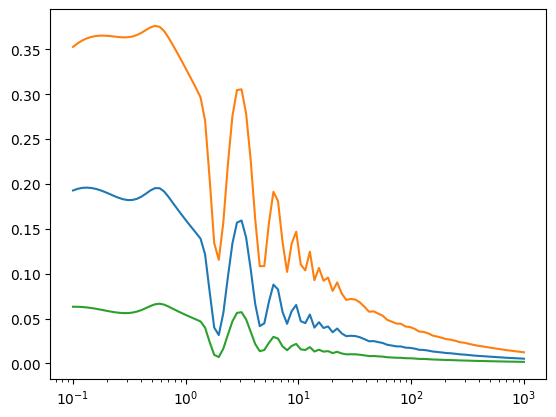

In [79]:
plot(taus,1/2-P1)
plot(taus,1/2-P2)
plot(taus,1/2-P0)

xscale("log")

In [91]:
file = "data/states_L=512_N=1000_log=True_tau0=-2_tauf=3.npz"
dat = np.load(file,allow_pickle=True)
dat

NpzFile 'data/states_L=512_N=1000_log=True_tau0=-2_tauf=3.npz' with keys: states, taus

In [102]:
taus= np.logspace(-1,3,100)
states = array([state(256,tau,tau) for tau in taus])

In [109]:

n_test = 10

Papprox = array([P_n(n_test,tau) for tau in taus])
Preal =  array([Px(n_test,state) for state in states])

[]

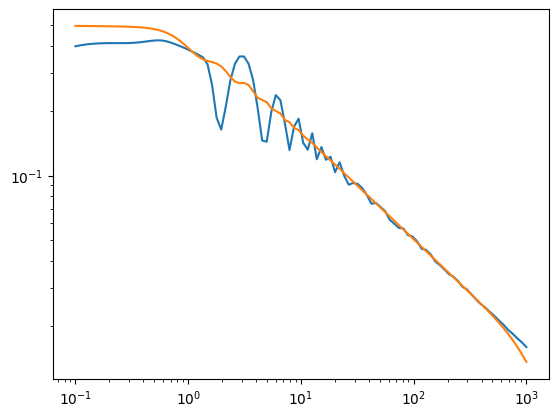

In [110]:
plot(taus,1/2-Papprox)
plot(taus,1/2-Preal)
loglog()